# **Librerías**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from pathlib import Path
import plotly.express as px
import squarify

# **Cargar el Dat Set**

In [8]:

# NO MODIFICAR LAS SIGUIENTES 2 LÍNEAS, YA QUE MUESTRAN MEJOR EL DATAFRAME AL HACER "PRINT" O "HEAD"
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.options.display.float_format = '{:,.0f}'.format

In [9]:
from pathlib import Path
import pandas as pd

ruta = Path.cwd().parent / "data" / "05.02.2026 EXTRACCION VIVIENDA FR.xlsx"

df = pd.read_excel(ruta)

X = df.drop(columns=["Precio"])
y = df["Precio"]


In [10]:
df = pd.concat([X, y], axis=1)

display(df.head())

,ID,Barrio,Tipo de Inmueble,Estado,Antigüedad,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,URL,Precio
0,193673918,Boston,Apartamento,Usado,NaN,60,60,4,2,3,0,4,https://wwwfincaraizcomco/apartamento-en-arrie...,1700000
1,193622107,Manrique,Casa,Usado,16 a 30 años,130,130,2,2,3,0,3,https://wwwfincaraizcomco/casa-en-arriendo-en-...,2200000
2,193621915,Robledo,Apartamento,Usado,más de 30 años,52,52,3,1,3,0,12,https://wwwfincaraizcomco/apartamento-en-arrie...,1400000
3,193550885,El Poblado,Apartamento,Usado,9 a 15 años,95,95,6,2,3,2,10,https://wwwfincaraizcomco/apartamento-en-arrie...,5100000
4,193459016,La salle,Apartamento,Usado,16 a 30 años,114,114,5,2,3,1,NaN,https://wwwfincaraizcomco/apartamento-en-arrie...,4200000


## Limpieza de datos

In [11]:
import unicodedata

def limpiar_texto(texto):
    if pd.isna(texto):
        return texto
    
    # quitar tildes
    texto = ''.join(
        c for c in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(c)
    )
    
    return (
        texto
        .strip()
        .upper()
        .replace('\n', ' ')
    )

df['Barrio_clean'] = df['Barrio'].apply(limpiar_texto)
df['Barrio_clean'] = df['Barrio_clean'].str.replace(r'\s+', ' ', regex=True)

In [12]:
df.groupby('Barrio_clean').size().sort_values(ascending=False)

Barrio_clean
EL POBLADO              967
LAURELES                613
BELEN                   291
CALASANZ                257
LAS PALMAS              166
                       ... 
TRANSVERSAL INFERIOR      1
TRICENTENARIO             1
VILLA DEL PARQUE          1
VILLATINA                 1
ZUNIGA                    1
Length: 231, dtype: int64

In [13]:
frecuencia = df['Barrio_clean'].value_counts()

barrios_validos = frecuencia[frecuencia >= 5].index

df['Barrio_group'] = df['Barrio_clean'].apply(
    lambda x: x if x in barrios_validos else 'OTROS'
)



In [14]:
df.groupby('Barrio_group').size().sort_values(ascending=False)

Barrio_group
EL POBLADO              967
LAURELES                613
BELEN                   291
CALASANZ                257
OTROS                   230
                       ... 
CARLOS E RESTREPO         5
LOS NARANJOS              5
LAS GRANJAS               5
SAN ANTONIO DE PRADO      5
LOS PINOS                 5
Length: 115, dtype: int64

# **Checamos la variable Target Y, que en nuestro caso es `Precio`**


In [15]:
df['Precio'].describe()

count         5,628
mean      5,120,721
std      19,181,197
min         450,000
25%       2,350,000
50%       3,500,000
75%       5,000,000
max     750,000,000
Name: Precio, dtype: float64

**Observación**

Vemos que la variable precio tiene un Max de 750 millones (posiblemente en el scraping se nos escaparon propiedades en venta) y un min de 450 mil(posiblemente de una habitación en arriendo)

In [16]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

fig = make_subplots(rows=1, cols=3, subplot_titles=["Distribución de Precio", "Boxplot de Precio", "Distribución de log(Precio)"])

fig.add_trace(go.Histogram(x=df["Precio"], name="Precio", showlegend=False), row=1, col=1)

fig.add_trace(go.Box(x=df["Precio"], name="Precio", showlegend=False), row=1, col=2)

fig.add_trace(go.Histogram(x=np.log1p(df["Precio"]), name="log(Precio)", showlegend=False), row=1, col=3)

fig.update_layout(title="Análisis de Precio", height=400, width=1500)
fig.show()


**Oservación**

La gráfica ya nos cuenta que la distribución inicial de nuestra variable `Precio` si esta muy sesgada a la derecha, y vemos unos cuantos outliers, los cuales podríamos inferir son las propiedades en venta, pero si usamos una distribución logarítmica, podemos observar mejor la distribución.

In [17]:
df_filtrado = df[(df["Precio"] >= 500_000) & (df["Precio"] <= 50_000_000)].copy()


**Observación**

Hacemos filtrado de precio con Minimo 500,000 y 50 millones ya que dentro de la plataforma de Finca Raiz, hay unas cuentas propiedades con este precio de arriendo

In [18]:
print(f"Filas originales: {len(df)}")
print(f"Filas filtradas: {len(df_filtrado)}")
print(f"Filas eliminadas: {len(df) - len(df_filtrado)}")
print(f"Porcentaje eliminado: {((len(df) - len(df_filtrado)) / len(df) * 100):.2f}%")


Filas originales: 5628
Filas filtradas: 5612
Filas eliminadas: 16
Porcentaje eliminado: 0.28%


In [19]:
fig = make_subplots(rows=1, cols=3, subplot_titles=["Distribución de Precio Filtrado", "Boxplot de Precio Filtrado", "Distribución de log(Precio) Filtrado"])

fig.add_trace(go.Histogram(x=df_filtrado["Precio"], name="Precio", showlegend=False), row=1, col=1)

fig.add_trace(go.Box(x=df_filtrado["Precio"], name="Precio", showlegend=False), row=1, col=2)

# A una escala logarítmica, para ver la distribución mas normalizada de los precios
fig.add_trace(go.Histogram(x=np.log1p(df_filtrado["Precio"]), name="log(Precio)", showlegend=False), row=1, col=3)

fig.update_layout(title="Análisis de Precio Filtrado", height=400, width=1000)
fig.show()

**Observación**

Aun después del filtrado de Precio entre 500.000 y 50.000.000, la distribución continúa sesgada a la derecha, con concentración de observaciones en valores bajos y medios, y una cola larga hacia precios altos. El boxplot evidencia la presencia de valores altos atípicos, que no necesariamente corresponden a errores, sino a inmuebles en arriendo de segmentos más costosos dentro de la plataforma. Al aplicar una transformación logarítmica, la distribución se vuelve más simétrica, lo que hace de log(Precio) una alternativa más apropiada para análisis posteriores.

# **Heatmap de Correlaciones!**

In [20]:
df_filtrado.columns

Index(['ID', 'Barrio', 'Tipo de Inmueble', 'Estado', 'Antigüedad',
       'Área Construida (m2)', 'Área Privada (m2)', 'Estrato', 'Baños',
       'Habitaciones', 'Parqueaderos', 'Piso N°', 'URL', 'Precio',
       'Barrio_clean', 'Barrio_group'],
      dtype='str')

In [21]:
cols_numericas = ["Estrato", "Baños", "Habitaciones", "Piso N°", 
                  "Área Construida (m2)", "Área Privada (m2)", 
                  "Parqueaderos", "Precio"]

corr = df_filtrado[cols_numericas].corr().round(2)

fig = px.imshow(corr, 
                text_auto=True, 
                color_continuous_scale="RdBu_r",
                title="Correlación entre variables numéricas",
                width=700, height=600)
fig.show()

**Observación**

1. Notamos una correlación muy alta entre las variables de `Área`, lo que sugiere que ambas contienen casi la misma información. También vemos una relación fuerte entre `Baños` y `Precio` (`0.68`), incluso mayor que la del área. Además, `Baños` y `Habitaciones` también presentan una alta correlación, algo esperable porque, por lo general, a mayor número de habitaciones, mayor número de baños.

2. La relación entre `Estrato` y `Precio` es de `0.47`, lo que indica que esta variable sí influye en el precio. Algo similar ocurre con `Habitaciones` y `Baños`, que también muestran una relación importante con esta variable.

3. Finalmente, observamos que `Piso N°` tiene una correlación baja con `Precio`, por lo que podría considerarse eliminarla más adelante si vemos que no aporta mucho al análisis o al modelo.



# **Limpieza e imputación de datos**

In [22]:
df_filtrado.info()

<class 'pandas.DataFrame'>
Index: 5612 entries, 0 to 5627
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5612 non-null   int64  
 1   Barrio                5612 non-null   str    
 2   Tipo de Inmueble      5612 non-null   str    
 3   Estado                5612 non-null   str    
 4   Antigüedad            4218 non-null   str    
 5   Área Construida (m2)  5489 non-null   float64
 6   Área Privada (m2)     5489 non-null   float64
 7   Estrato               5561 non-null   float64
 8   Baños                 5570 non-null   float64
 9   Habitaciones          5521 non-null   float64
 10  Parqueaderos          5612 non-null   int64  
 11  Piso N°               2929 non-null   float64
 12  URL                   5612 non-null   str    
 13  Precio                5612 non-null   int64  
 14  Barrio_clean          5612 non-null   str    
 15  Barrio_group          5612 non-null  

In [23]:
# Cambiar de tipo de variable de ID a string
df["ID"] = df["ID"].astype(str)

## **Análisis de Valores Nulos**

### **Valores Nulos**

In [24]:
nulos = pd.DataFrame({
    'Nulos': df_filtrado.isnull().sum(),
    '% Nulos': (df_filtrado.isnull().mean() * 100).round(2)
})
nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

,Nulos,% Nulos
Piso N°,2683,48
Antigüedad,1394,25
Área Construida (m2),123,2
Área Privada (m2),123,2
Habitaciones,91,2
Estrato,51,1
Baños,42,1


In [25]:
nulos_filtrado = nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

fig = px.bar(nulos_filtrado, x=nulos_filtrado.index, y='% Nulos',
             text='% Nulos',
             title="Porcentaje de Valores Faltantes por Variable",
             labels={'x': 'Variable', '% Nulos': '% Nulos'},
             width=800, height=400)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(
    xaxis_tickangle=-30,
    yaxis_range=[0, nulos_filtrado['% Nulos'].max() * 1.15]
)
fig.show()

**Observación**

Podemos ver que las variables `Piso N°` y `Antigüedad` presentan mas valores faltantes, se podría observar la hipótesis de si esos valores faltantes de la variable `Piso N°` es porque son casas y no apartamentos.

### **Checamos la variable `Piso N°`**

In [26]:
# Analicemos la cantidad de datos faltantes por variable = "Piso N°"

df_filtrado[df_filtrado['Piso N°'].isnull()]['Tipo de Inmueble'].value_counts()

Tipo de Inmueble
Apartamento      2033
Casa              457
Apartaestudio     193
Name: count, dtype: int64

In [27]:
conteo = df_filtrado[df_filtrado['Piso N°'].isnull()]['Tipo de Inmueble'].value_counts()

fig = px.pie(values=conteo.values, names=conteo.index,
             title="Nulos en Piso N° por Tipo de Inmueble",
             width=600, height=400)
fig.show()

**Observación**

La hipótesis queda rechazada puesto que los apartamentos son los valores que presentan el mayor número de valores faltantes, mientras que casa tiene 457, la idea es imputar casa con 1 directamente, ya que son de un solo piso. Los nulos restantes (Apartamentos y Apartaestudios) se tratarán con KNNImputer.

In [28]:
df_filtrado.columns

Index(['ID', 'Barrio', 'Tipo de Inmueble', 'Estado', 'Antigüedad',
       'Área Construida (m2)', 'Área Privada (m2)', 'Estrato', 'Baños',
       'Habitaciones', 'Parqueaderos', 'Piso N°', 'URL', 'Precio',
       'Barrio_clean', 'Barrio_group'],
      dtype='str')

In [29]:
df_casas = df_filtrado[df_filtrado['Tipo de Inmueble'] == 'Casa'].copy()
df_casas['Piso N°'].value_counts(dropna=False)

Piso N°
NaN    457
1      249
2      115
3       24
4        4
7        1
Name: count, dtype: int64

In [30]:
# Analizamos la variable barrio para ver la cantidad de inmuebles para su posible imputación con KNN
df_filtrado.groupby('Barrio_clean').size().sort_values(ascending=False)

Barrio_clean
EL POBLADO              965
LAURELES                613
BELEN                   290
CALASANZ                257
LAS PALMAS              165
                       ... 
TRANSVERSAL SUPERIOR      1
TRICENTENARIO             1
VILLA DEL PARQUE          1
VILLATINA                 1
ZUNIGA                    1
Length: 231, dtype: int64

In [31]:
df_filtrado['Piso N°'] = df_filtrado['Piso N°'].replace({7: np.nan})

In [32]:
def piso_cat(x):
    if pd.isna(x):
        return 'missing'
    elif x == 1:
        return '1'
    elif x == 2:
        return '2'
    else:
        return '3+'

df_filtrado['Piso_cat'] = df_filtrado['Piso N°'].apply(piso_cat)

In [33]:
df_filtrado.groupby('Piso_cat').size()

Piso_cat
1           605
2           488
3+         1726
missing    2793
dtype: int64

In [34]:
#Imputamos los datos faltantes de "Piso N°" con el valor 1, ya que es lo más lógico para las casas, ya que no suelen tener más de un piso.
df_filtrado.loc[(df_filtrado['Piso N°'].isnull()) & (df_filtrado['Tipo de Inmueble']== "Casa"), "Piso N°"] = 1

In [35]:
# Verificamos que se haya imputado correctamente
df_filtrado[df_filtrado["Tipo de Inmueble"] == "Casa"]["Piso N°"].isnull().sum()

np.int64(0)

### **Checamos la variable `Antigüedad`**

In [36]:
df_filtrado['Antigüedad'].value_counts()

Antigüedad
1 a 8 años        1300
16 a 30 años      1243
9 a 15 años        742
más de 30 años     521
menor a 1 año      412
Name: count, dtype: int64

In [37]:
conteo = df_filtrado['Antigüedad'].value_counts()

fig = px.bar(x=conteo.index, y=conteo.values,
             text=conteo.values,
             title="Distribución de Antigüedad",
             labels={'x': 'Antigüedad', 'y': 'Cantidad'},
             width=800, height=600)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [38]:
# Cruce con precio para ver si influye
df_filtrado.groupby("Antigüedad")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Antigüedad,,,,,,,,
1 a 8 años,"1,300","4,602,072","4,137,479","550,000","2,500,000","3,600,000","5,300,000","45,000,000"
16 a 30 años,"1,243","4,402,568","4,198,999","550,000","2,350,000","3,400,000","4,725,000","50,000,000"
9 a 15 años,742,"4,645,309","3,681,708","550,000","2,562,500","3,800,000","5,500,000","45,000,000"
menor a 1 año,412,"3,842,633","3,284,419","920,000","2,275,000","3,000,000","4,200,000","38,000,000"
más de 30 años,521,"4,619,825","4,739,287","750,000","2,100,000","3,200,000","5,200,000","45,000,000"


In [39]:
df_filtrado["Precio"].describe()

count        5,612
mean     4,425,405
std      4,077,955
min        500,000
25%      2,350,000
50%      3,500,000
75%      5,000,000
max     50,000,000
Name: Precio, dtype: float64

**Observación**
1. 1 a 8 años: tiene el promedio de precios más alto, con 4,828,463, podemos inferir que los inmuebles más modernos se arriendan a mayor valor.
2. **menor a 1 año** tiene el promedio más bajo ($3,842,633), posiblemente porque son proyectos nuevos en zonas periféricas aún en consolidación.
4. La **antigüedad no parece ser el factor más determinante del precio**, ya que los promedios entre categorías son bastante similares. Variables como barrio y estrato probablemente tienen mayor peso.




In [40]:
df_filtrado.groupby("Barrio")["Antigüedad"].agg(
    total = "count",
    nulos = lambda x: x.isnull().sum(),
    moda = lambda x: x.mode()[0] if not x.mode().empty else "Sin moda"
).reset_index().sort_values("nulos", ascending=False).head(20)

,Barrio,total,nulos,moda
160,Laureles,434,165,16 a 30 años
94,El Poblado,856,108,16 a 30 años
33,Belén,213,73,16 a 30 años
57,Calasanz,207,50,1 a 8 años
170,Loma del Indio,109,48,1 a 8 años
158,Las palmas,119,45,1 a 8 años
224,San diego,65,40,1 a 8 años
54,Buenos aires,104,35,más de 30 años
81,Conquistadores,32,33,1 a 8 años
71,Centro,38,32,16 a 30 años


**Observación**

La opción mas lógica para imputar en este caso es por barrio, considerando que la moda de la variable `Antigüedad` en barrios como Laureles, El Poblado y Belén son apartamentos mas viejos, mientras que zonas como El Velodromo, Calasanz, presentan un desarrollo creciente. E igualmente, se puede ver que el barrio con mas valores faltantes es Laureles.

In [41]:
# Para cada barrio, rellena los nulos de Antigüedad con el valor de antigüedad más común en ese mismo barrio. Si el barrio no tiene ningún dato de antigüedad, ponemos 'Desconocido'.
df_filtrado['Antigüedad'] = df_filtrado.groupby('Barrio')['Antigüedad'].transform(
                              lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else "Desconocido")

In [42]:
df_filtrado["Antigüedad"].isnull().sum()

np.int64(0)

### **Checamos la variable `Área Construida (m2)` y `Área Privada (m2)`**

Inicialmente notamos que 

`Área Construida (m2)` y `Área Privada (m2) ` tienen la misma cantidad de valores nulos, lo podemos confirmar 123.

In [43]:
# Confirmamos que ambas columnas tienen exactamente las mismas filas nulos
print((df["Área Construida (m2)"].isnull() == df["Área Privada (m2)"].isnull()).all())

True


**Observación**

Decidimos que lo mejor es mputar ambas variables con KNNImputer ya que son exactamente los mismos registros y ambas se pueden estimar mucho mejor a partir de las otras variables presentes, como "Habitaciones", "Baños" etc.

In [44]:
df_filtrado["Área Construida (m2)"].describe()

count    5,489
mean       414
std      2,252
min          1
25%         60
50%         80
75%        120
max     55,200
Name: Área Construida (m2), dtype: float64

In [45]:
conteo = df_filtrado[df_filtrado["Área Construida (m2)"] < 20]["Tipo de Inmueble"].value_counts()

fig = px.bar(x=conteo.index, y=conteo.values,
             text=conteo.values,
             title="Inmuebles < 20 m² por Tipo de Inmueble",
             labels={'x': 'Tipo de Inmueble', 'y': 'Cantidad'},
             width=600, height=600)

fig.update_traces(textposition='outside')
fig.show()

**Observación**

Podemos ver que los Tipos de Inmueble sospechosamente mas pequeos son los apartaestudios, lo cual tiene mucho sentido.

In [46]:
# Ver si son exactamente las mismas filas
print((df_filtrado["Área Construida (m2)"].isnull() == df_filtrado["Área Privada (m2)"].isnull()).all())

True


In [47]:
fig = px.box(df_filtrado[df_filtrado["Área Construida (m2)"] <= 500], 
             x="Tipo de Inmueble", y="Área Construida (m2)",
             title="Área Construida por Tipo de Inmueble",
             width=600, height=400)
fig.show()

**Observación**

El área construida sigue un orden lógico según el tipo de inmueble: 
1. Apartaestudio (~40 m²) 
2. Apartamento (~80 m²) 
3. Casa (~185 m²), lo cual es coherente con la realidad del mercado de Medellín.

### **Checamos la variable `Estrato`**


In [48]:
# Distribución general
conteo = df_filtrado["Estrato"].value_counts().sort_values(ascending=False).reset_index()
conteo.columns = ["Estrato", "Cantidad"]
conteo["Estrato"] = conteo["Estrato"].astype(str)

fig = px.bar(conteo, x="Estrato", y="Cantidad",
             text="Cantidad",
             title="Distribución de Estrato",
             labels={'Estrato': 'Estrato', 'Cantidad': 'Cantidad'},
             width=600, height=500)

fig.update_traces(textposition='outside')
fig.update_layout(bargap=0.3)
fig.show()

In [49]:
# Miramos el estrato por barrio para ver si tiene sentido, en este caso se ve la moda y los nulos
df_filtrado.groupby("Barrio")["Estrato"].agg(
    moda=lambda x: x.mode()[0] if not x.mode().empty else "Sin moda",
    nulos=lambda x: x.isnull().sum()
).sort_values("nulos", ascending=False).head(20)

,moda,nulos
Barrio,,
Belén,4,6
Cristo rey,4,4
Prado,4,4
Boston,4,3
Calasanz,4,3
La candelaria,4,3
La Almeria,5,2
Simon bolivar,5,2
Guayaquil,5,2


**Observación**

Según los datos, imputamos con la moda. En San Benito, como no había una moda definida, usamos la mediana, que fue 3.

In [50]:
# Imputamos Estrato por moda de barrio
df_filtrado["Estrato"] = df_filtrado.groupby("Barrio")["Estrato"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())
)

In [51]:
# Verificamos los Nulos de Estrato, que son los que representan al barrio San Benito
print(df_filtrado["Estrato"].isnull().sum())

2


In [52]:
df_filtrado.loc[df_filtrado["Barrio"] == "San benito", "Estrato"] = 3

### **Imputación de variables `Baños`, `Habitaciones`, `Piso N°`, `Área Construida (m2)` y `Área Privada (m2)`**

Para imputar los valores faltantes en las variables numéricas, vamos a utilizar `KNNImputer` con 5 vecinos. Esta elección es adecuada porque varias de estas variables presentan relaciones entre sí, como se observó en el heat map; por ejemplo, `Baños` y `Habitaciones` (`0.63`), y `Área Construida (m2)` y `Área Privada (m2)` (`0.97`). Esto permite estimar los valores faltantes a partir de inmuebles con características similares. Se eligieron 5 vecinos como un valor intermedio, buscando un equilibrio para captar patrones cercanos


In [53]:
# Remplazar las variables numéricas faltantes utilizando KNNImputer

cols_int = ["Baños", "Habitaciones", "Piso N°"]
cols_float = ["Área Construida (m2)", "Área Privada (m2)"]
cols_all = cols_int + cols_float

imputer = KNNImputer(n_neighbors=5)
df_filtrado[cols_all] = imputer.fit_transform(df_filtrado[cols_all]) 

# cambiamos de tipo de variable a int y float
df_filtrado[cols_int] = df_filtrado[cols_int].astype(int)
# cambiamos de tipo de variable a float
df_filtrado[cols_float] = df_filtrado[cols_float].astype(float)

In [54]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

cols_all = ["Baños", "Habitaciones", "Piso N°", "Área Construida (m2)", "Área Privada (m2)"]

fig = make_subplots(rows=1, cols=5, subplot_titles=cols_all)

for i, col in enumerate(cols_all):
    fig.add_trace(
        go.Box(y=df_filtrado[col], name=col, showlegend=False),
        row=1, col=i+1
    )

fig.update_layout(title="Distribución de variables imputadas con KNN", 
                  height=400, width=900)
fig.show()

**Observación**

1. Hacemos `fit.transform`por ahora, pero en la fase de modelado cuando hagamos el split de datos, tenemos que corregir esto para que no haya data leakage
2. Tenemos que revisar esos outliers de 25 baños, 25 habitaciones...

# **Como quedaron nuestras variables:**

In [55]:
df_filtrado.info()

<class 'pandas.DataFrame'>
Index: 5612 entries, 0 to 5627
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5612 non-null   int64  
 1   Barrio                5612 non-null   str    
 2   Tipo de Inmueble      5612 non-null   str    
 3   Estado                5612 non-null   str    
 4   Antigüedad            5612 non-null   str    
 5   Área Construida (m2)  5612 non-null   float64
 6   Área Privada (m2)     5612 non-null   float64
 7   Estrato               5612 non-null   float64
 8   Baños                 5612 non-null   int64  
 9   Habitaciones          5612 non-null   int64  
 10  Parqueaderos          5612 non-null   int64  
 11  Piso N°               5612 non-null   int64  
 12  URL                   5612 non-null   str    
 13  Precio                5612 non-null   int64  
 14  Barrio_clean          5612 non-null   str    
 15  Barrio_group          5612 non-null  

# **Exploración de Variables Categóricas**

In [56]:
df_filtrado.columns

Index(['ID', 'Barrio', 'Tipo de Inmueble', 'Estado', 'Antigüedad',
       'Área Construida (m2)', 'Área Privada (m2)', 'Estrato', 'Baños',
       'Habitaciones', 'Parqueaderos', 'Piso N°', 'URL', 'Precio',
       'Barrio_clean', 'Barrio_group', 'Piso_cat'],
      dtype='str')

In [57]:
display(df_filtrado.head())

,ID,Barrio,Tipo de Inmueble,Estado,Antigüedad,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,URL,Precio,Barrio_clean,Barrio_group,Piso_cat
0,193673918,Boston,Apartamento,Usado,16 a 30 años,60,60,4,2,3,0,4,https://wwwfincaraizcomco/apartamento-en-arrie...,1700000,BOSTON,BOSTON,3+
1,193622107,Manrique,Casa,Usado,16 a 30 años,130,130,2,2,3,0,3,https://wwwfincaraizcomco/casa-en-arriendo-en-...,2200000,MANRIQUE,MANRIQUE,3+
2,193621915,Robledo,Apartamento,Usado,más de 30 años,52,52,3,1,3,0,12,https://wwwfincaraizcomco/apartamento-en-arrie...,1400000,ROBLEDO,ROBLEDO,3+
3,193550885,El Poblado,Apartamento,Usado,9 a 15 años,95,95,6,2,3,2,10,https://wwwfincaraizcomco/apartamento-en-arrie...,5100000,EL POBLADO,EL POBLADO,3+
4,193459016,La salle,Apartamento,Usado,16 a 30 años,114,114,5,2,3,1,6,https://wwwfincaraizcomco/apartamento-en-arrie...,4200000,LA SALLE,OTROS,missing


In [58]:
df_filtrado.describe()

,ID,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,Precio
count,"5,612","5,612","5,612","5,612","5,612","5,612","5,612","5,612","5,612"
mean,"188,960,690",412,411,4,2,3,1,5,"4,425,405"
std,"27,987,156","2,229","2,171",1,1,1,3,5,"4,077,955"
min,"6,801,368",1,1,1,1,1,0,1,"500,000"
25%,"193,281,552",60,60,4,2,2,0,2,"2,350,000"
50%,"193,550,856",80,80,4,2,3,1,4,"3,500,000"
75%,"193,638,743",120,120,5,3,3,1,8,"5,000,000"
max,"193,688,846","55,200","55,200",6,20,25,127,97,"50,000,000"


## **Variables Categóricas `Estado`, `Tipo de Inmueble`, `Antigüedad`**

In [59]:
df_filtrado["Estado"].value_counts()

Estado
Usado               4969
Buen estado          394
Nuevo                161
Excelente estado      88
Name: count, dtype: int64

In [60]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

conteo = df_filtrado["Estado"].value_counts()

fig = make_subplots(rows=1, cols=2, subplot_titles=["Distribución", "Precio por Estado"])

fig.add_trace(
    go.Bar(x=conteo.index, y=conteo.values, text=conteo.values, textposition='outside', showlegend=False),
    row=1, col=1
)

for estado in df_filtrado["Estado"].unique():
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Estado"] == estado]["Precio"], name=estado, showlegend=False),
        row=1, col=2
    )

fig.update_layout(title="Estado", height=500, width=900)
fig.show()

In [61]:
df["Tipo de Inmueble"].value_counts()

Tipo de Inmueble
Apartamento      4144
Casa              856
Apartaestudio     628
Name: count, dtype: int64

In [62]:
conteo = df_filtrado["Tipo de Inmueble"].value_counts()

fig = make_subplots(rows=1, cols=2, subplot_titles=["Distribución", "Precio por Tipo de Inmueble"])

fig.add_trace(
    go.Bar(x=conteo.index, y=conteo.values, text=conteo.values, textposition='outside', showlegend=False),
    row=1, col=1
)

for tipo in df_filtrado["Tipo de Inmueble"].unique():
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Tipo de Inmueble"] == tipo]["Precio"], name=tipo, showlegend=False),
        row=1, col=2
    )

fig.update_layout(title="Tipo de Inmueble", height=500, width=900)
fig.show()

In [63]:
df["Antigüedad"].value_counts()

Antigüedad
1 a 8 años        1305
16 a 30 años      1246
9 a 15 años        743
más de 30 años     522
menor a 1 año      412
Name: count, dtype: int64

In [64]:
orden = ["menor a 1 año", "1 a 8 años", "9 a 15 años", "16 a 30 años", "más de 30 años", "Desconocido"]

conteo = df_filtrado["Antigüedad"].value_counts().reindex(orden)

fig = make_subplots(rows=1, cols=2, subplot_titles=["Distribución", "Precio por Antigüedad"])

fig.add_trace(
    go.Bar(x=conteo.index, y=conteo.values, text=conteo.values, textposition='outside', showlegend=False),
    row=1, col=1
)

for antiguedad in orden:
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Antigüedad"] == antiguedad]["Precio"], name=antiguedad, showlegend=False),
        row=1, col=2
    )

fig.update_layout(title="Antigüedad", height=500, width=900)
fig.show()

# **Cruce con respecto al precio**

**1. Precio por `Estrato`**

In [65]:
df_filtrado.groupby("Estrato")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Estrato,,,,,,,,
1,11,"2,281,818","1,473,844","1,020,000","1,100,000","1,980,000","2,650,000","5,200,000"
2,127,"1,611,756","1,171,286","500,000","1,010,000","1,300,000","1,725,000","9,600,000"
3,"1,039","2,132,174","1,931,555","550,000","1,350,000","1,800,000","2,500,000","38,000,000"
4,"1,649","3,287,631","2,152,418","800,000","2,300,000","2,900,000","3,600,000","34,000,000"
5,"1,548","4,740,593","3,055,797","700,000","3,200,000","3,950,000","5,200,000","30,000,000"
6,"1,238","7,779,086","5,993,052","1,900,000","4,300,000","5,900,000","8,500,000","50,000,000"


In [66]:
fig = px.box(df_filtrado, x="Estrato", y="Precio",
             title="Precio por Estrato",
             labels={"Estrato": "Estrato", "Precio": "Precio"},
             width=700, height=400)
fig.show()

**2. Precio por `Estrato`**

In [67]:
df_filtrado.groupby("Antigüedad")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Antigüedad,,,,,,,,
1 a 8 años,"1,877","4,549,476","4,113,503","550,000","2,500,000","3,500,000","5,000,000","45,000,000"
16 a 30 años,"1,849","4,438,124","4,225,518","500,000","2,300,000","3,400,000","4,800,000","50,000,000"
9 a 15 años,765,"4,680,182","3,758,255","550,000","2,550,000","3,800,000","5,500,000","45,000,000"
Desconocido,41,"3,433,171","2,840,018","1,000,000","1,700,000","2,450,000","4,100,000","14,000,000"
menor a 1 año,468,"3,703,985","3,223,554","800,000","2,000,000","2,975,000","4,025,000","38,000,000"
más de 30 años,612,"4,306,126","4,474,283","700,000","1,900,000","3,000,000","4,800,000","45,000,000"


In [68]:
orden = ["menor a 1 año", "1 a 8 años", "9 a 15 años", "16 a 30 años", "más de 30 años", "Desconocido"]

fig = px.box(df_filtrado, x="Antigüedad", y="Precio",
             category_orders={"Antigüedad": orden},
             title="Precio por Antigüedad",
             width=800, height=400)
fig.show()

**3. Precio por `Tipo de Inmueble`**

In [69]:
df_filtrado.groupby("Tipo de Inmueble")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Tipo de Inmueble,,,,,,,,
Apartaestudio,627,"2,306,882","2,494,684","500,000","1,250,000","1,700,000","2,500,000","35,000,000"
Apartamento,"4,135","4,124,694","2,756,787","550,000","2,511,000","3,500,000","4,800,000","45,000,000"
Casa,850,"7,450,994","7,442,482","750,000","3,000,000","4,500,000","9,000,000","50,000,000"


In [70]:
fig = px.box(df_filtrado, x="Tipo de Inmueble", y="Precio",
             title="Precio por Tipo de Inmueble",
             width=700, height=400)
fig.show()

**4. Precio por `Habitaciones`**

In [71]:
fig = make_subplots(rows=1, cols=1)

for hab in sorted(df_filtrado["Habitaciones"].unique()):
    fig.add_trace(
        go.Box(y=df_filtrado[df_filtrado["Habitaciones"] == hab]["Precio"], 
               name=str(int(hab)), showlegend=False),
    )

fig.update_layout(title="Precio por Habitaciones", height=400, width=700,
                  xaxis_title="Habitaciones", yaxis_title="Precio")
fig.show()

**5. Resumido de toda las gráficas de arriba:**

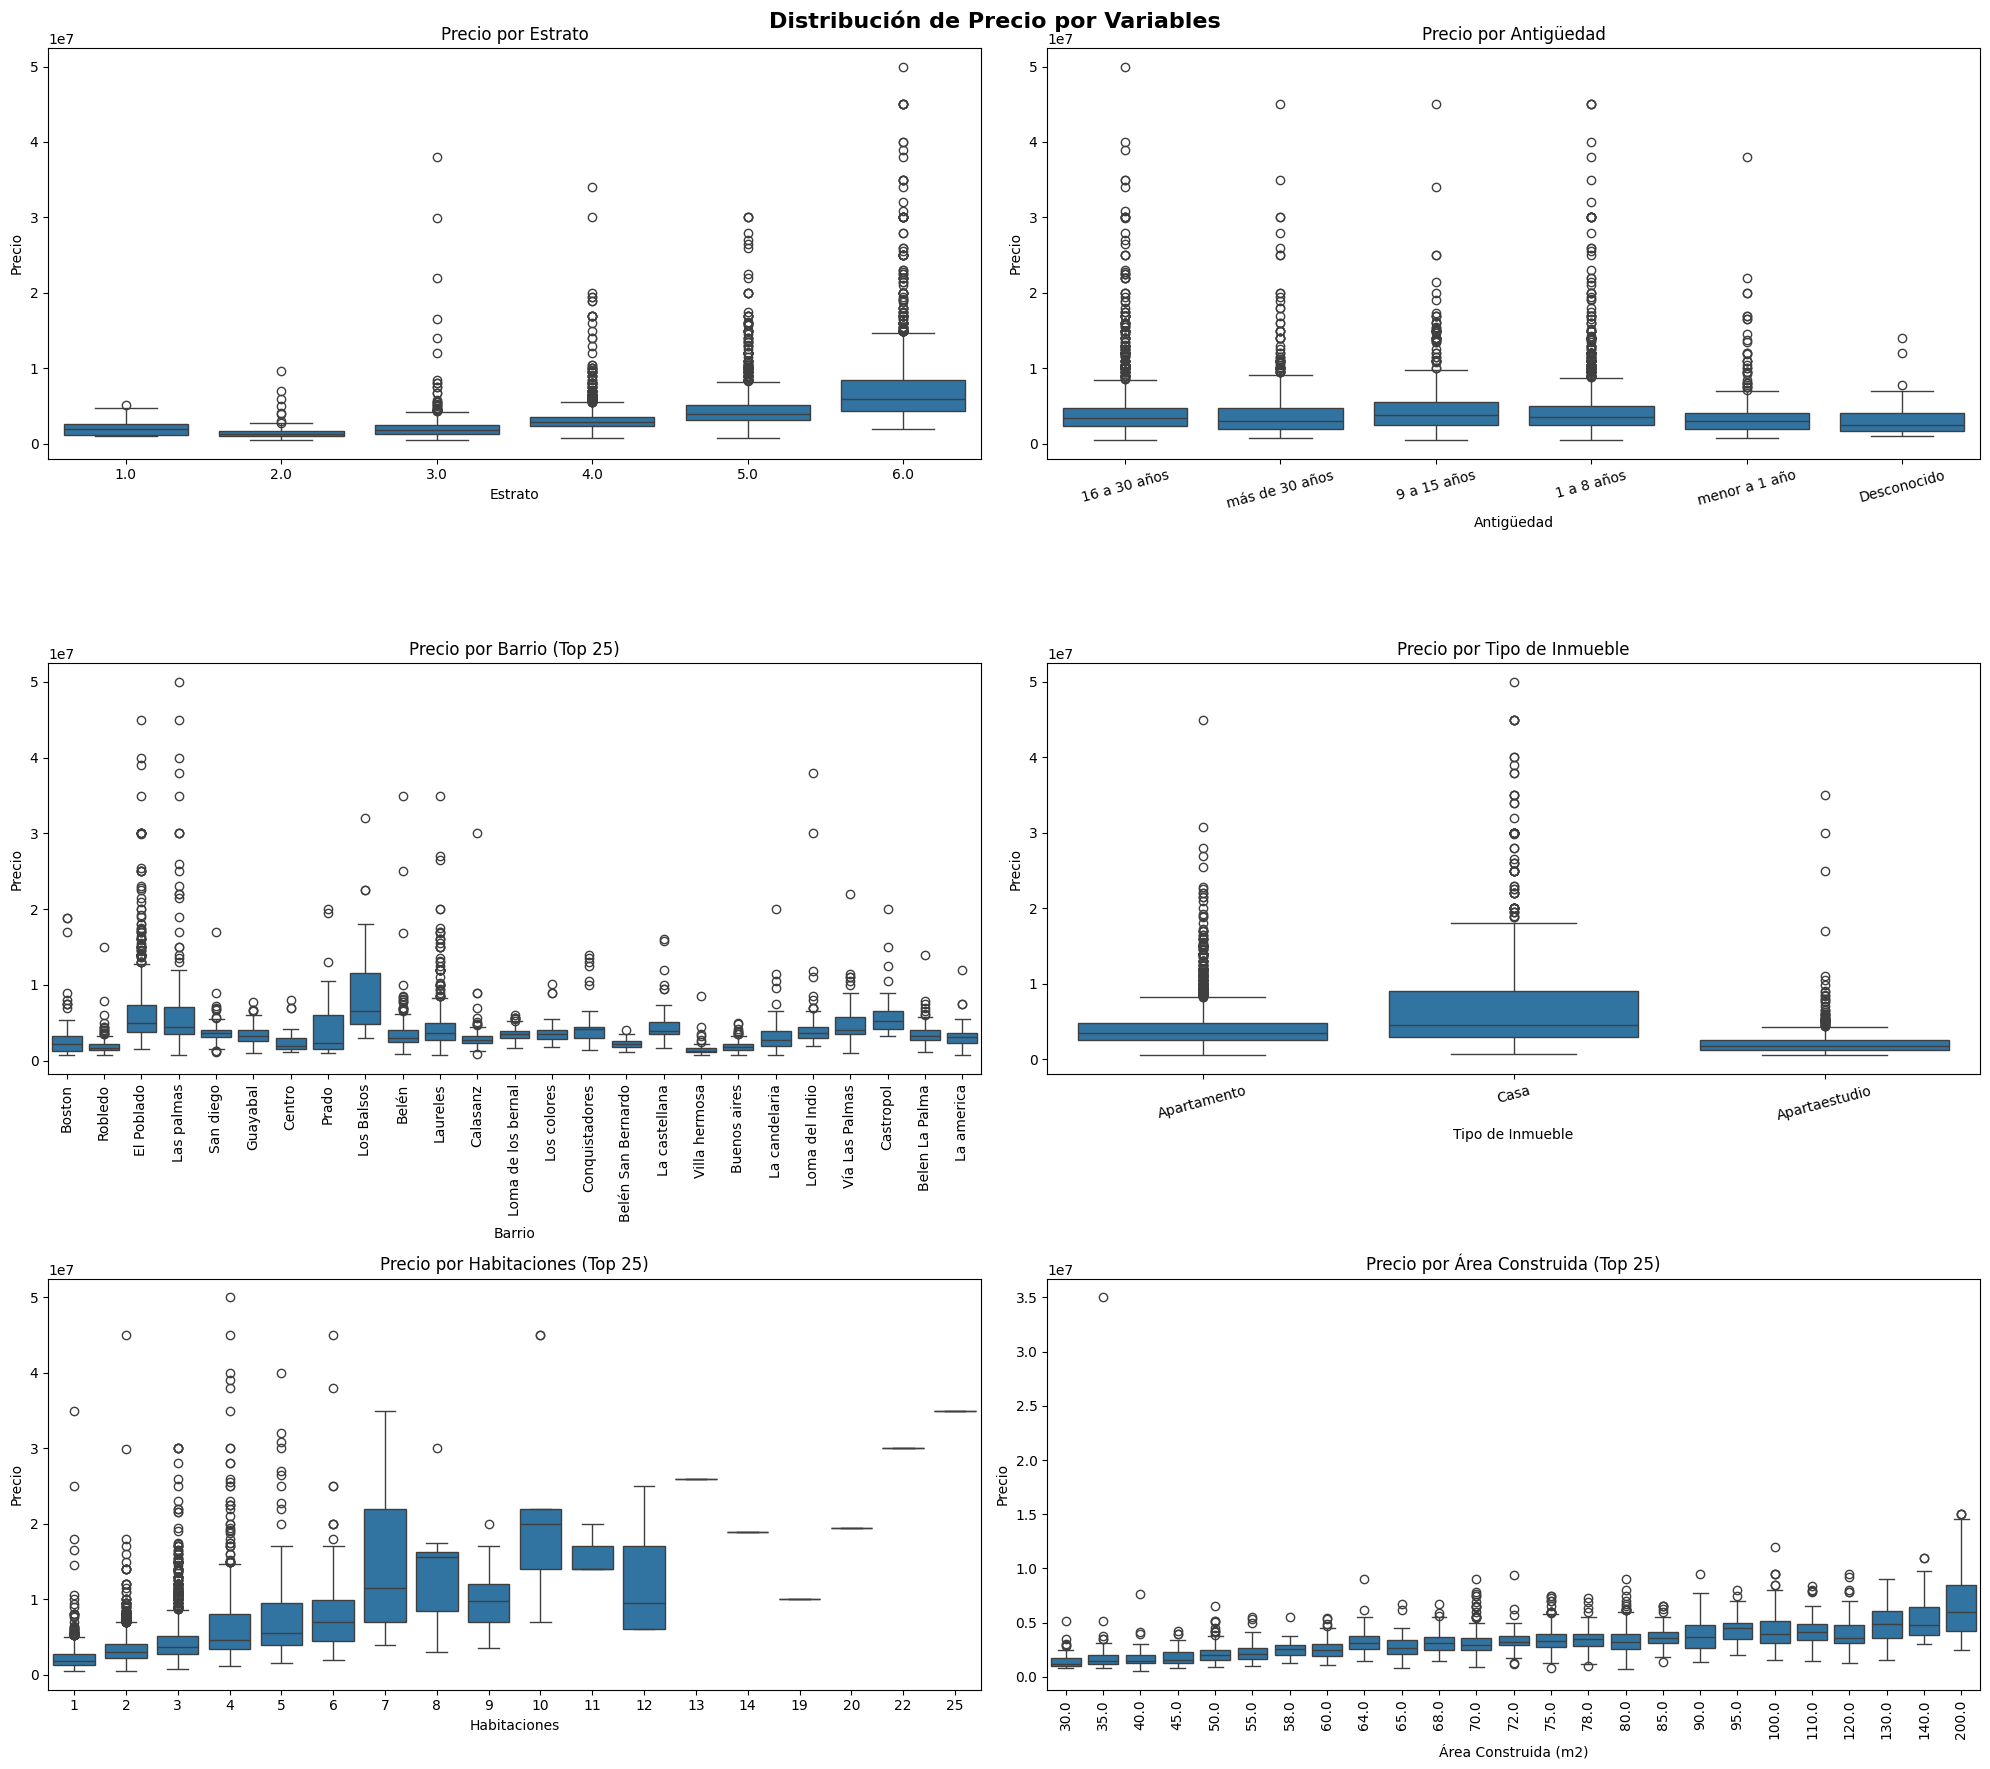

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 25 de cada variable
top_barrios = df_filtrado["Barrio"].value_counts().head(25).index
top_habitaciones = df_filtrado["Habitaciones"].value_counts().head(25).index
top_area = df_filtrado["Área Construida (m2)"].value_counts().head(25).index

# Filtros
df_barrio = df_filtrado[df_filtrado["Barrio"].isin(top_barrios)]
df_hab = df_filtrado[df_filtrado["Habitaciones"].isin(top_habitaciones)]
df_area = df_filtrado[df_filtrado["Área Construida (m2)"].isin(top_area)]

# Tablero
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle("Distribución de Precio por Variables", fontsize=16, fontweight="bold")

# 1. Estrato
sns.boxplot(data=df_filtrado, x="Estrato", y="Precio", ax=axes[0, 0])
axes[0, 0].set_title("Precio por Estrato")

# 2. Antigüedad
sns.boxplot(data=df_filtrado, x="Antigüedad", y="Precio", ax=axes[0, 1])
axes[0, 1].set_title("Precio por Antigüedad")
axes[0, 1].tick_params(axis="x", rotation=15)

# 3. Barrio (Top 25)
sns.boxplot(data=df_barrio, x="Barrio", y="Precio", ax=axes[1, 0])
axes[1, 0].set_title("Precio por Barrio (Top 25)")
axes[1, 0].tick_params(axis="x", rotation=90)

# 4. Tipo de Inmueble
sns.boxplot(data=df_filtrado, x="Tipo de Inmueble", y="Precio", ax=axes[1, 1])
axes[1, 1].set_title("Precio por Tipo de Inmueble")
axes[1, 1].tick_params(axis="x", rotation=15)

# 5. Habitaciones (Top 25)
sns.boxplot(data=df_hab, x="Habitaciones", y="Precio", ax=axes[2, 0])
axes[2, 0].set_title("Precio por Habitaciones (Top 25)")

# 6. Área Construida (Top 25)
sns.boxplot(data=df_area, x="Área Construida (m2)", y="Precio", ax=axes[2, 1])
axes[2, 1].set_title("Precio por Área Construida (Top 25)")
axes[2, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**6. Top 20 barrios con mayor oferta de inmuebles y su precio mediano de arriendo**

In [73]:
# Cantidad e inmuebles y precio promedio por barrio
df_tree = df_filtrado.groupby("Barrio").agg(
    cantidad=("Precio", "count"),
    precio_mediano=("Precio", "median")
).sort_values("cantidad", ascending=False).head(20).reset_index()

fig = px.treemap(df_tree, 
                 path=["Barrio"],
                 values="cantidad",
                 color="precio_mediano",
                 color_continuous_scale="Viridis",
                 title="Inmuebles por Barrio - Precio Mediano (Top 20)",
                 width=1500, height=600)

fig.update_traces(texttemplate="<b>%{label}</b><br>Cantidad: %{value}<br>Precio: $%{customdata[0]:,.0f}",
                  customdata=df_tree[["precio_mediano"]].values)
fig.show()

**7. Top 10 barrios más caros vs más baratos**

In [74]:
mediana_barrio = df_filtrado.groupby("Barrio")["Precio"].median().reset_index()
mediana_barrio.columns = ["Barrio", "Precio Mediana"]

top_caros = mediana_barrio.nlargest(10, "Precio Mediana")
top_baratos = mediana_barrio.nsmallest(10, "Precio Mediana")

fig = make_subplots(rows=1, cols=2, subplot_titles=["Top 10 Barrios más Caros", "Top 10 Barrios más Baratos"])

fig.add_trace(go.Bar(x=top_caros["Barrio"], y=top_caros["Precio Mediana"],
                     text=top_caros["Precio Mediana"].apply(lambda x: f"${x:,.0f}"),
                     textposition='outside', showlegend=False), row=1, col=1)

fig.add_trace(go.Bar(x=top_baratos["Barrio"], y=top_baratos["Precio Mediana"],
                     text=top_baratos["Precio Mediana"].apply(lambda x: f"${x:,.0f}"),
                     textposition='outside', showlegend=False), row=1, col=2)

fig.update_layout(title="Top 10 Barrios más Caros vs más Baratos", height=450, width=1000)
fig.update_xaxes(tickangle=-45)
fig.show()

# **Por qué es difícil fijar un precio de arriendo justo?**

In [75]:
# Apartamentos de 3 habitaciones estrato 4 — deberían costar similar
barrios_estrato4 = ["El Poblado", "Laureles"]

df_similar = df_filtrado[
    (df_filtrado["Habitaciones"] == 3) &
    (df_filtrado["Estrato"] == 4) &
    (df_filtrado["Tipo de Inmueble"] == "Apartamento") &
    (df_filtrado["Barrio"].isin(barrios_estrato4))
]

fig = px.histogram(df_similar, x="Precio", nbins=30,
                   color="Barrio",
                   title="Precios de Apartamentos: 3 hab, Estrato 4 por Barrio",
                   width=900, height=450)
fig.update_traces(marker_line_width=1, marker_line_color="white")
fig.update_layout(bargap=0.05)
fig.show()

**Observación**

Incluso comparando inmuebles relativamente parecidos, el precio sigue variando bastante entre barrios y también dentro del mismo barrio. Esto refuerza la idea de que el canon de arriendo no puede fijarse con una sola regla simple y que se necesita un modelo que combine varias variables.

**2. Distribución de precios para `Barrios` con mas registros en el dataset**

In [76]:
top_barrios = df_filtrado["Barrio"].value_counts().head(20).index

fig = px.box(df_filtrado[df_filtrado["Barrio"].isin(top_barrios)],
             x="Barrio", y="Precio",
             title="Precio por Barrio (Top 20)",
             width=1000, height=500)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

**Observación**

 la ubicación influye mucho en el canon. No es lo mismo un inmueble en un barrio que en otro, y además dentro de un mismo barrio también hay dispersión de precios. Eso indica que no basta con decir “es en Medellín” o “es en una buena zona”

**3. `Área Construida` vs precios por `Estrato`**

In [77]:
fig = px.scatter(df_filtrado[df_filtrado["Área Construida (m2)"] <= 500], 
                 x="Área Construida (m2)", y="Precio",
                 color="Estrato", opacity=0.4,
                 title="Área Construida vs Precio por Estrato",
                 width=800, height=450)
fig.show()

**Observación**

el precio no aumenta solo por el tamaño. Dos viviendas con áreas parecidas pueden tener precios distintos según su estrato. Eso evidencia que el valor depende de la combinación entre características físicas y contexto socioeconómico.

**4. ``Precio`` por ``Estrato`` + `Tipo de Inmueble` combinados** 

In [78]:
fig = px.box(df_filtrado, x="Estrato", y="Precio",
             color="Tipo de Inmueble",
             title="Precio por Estrato y Tipo de Inmueble",
             labels={"Estrato": "Estrato", "Precio": "Precio"},
             width=900, height=450)
fig.show()

**Observación**

dentro del mismo estrato el precio cambia según si es apartamento, casa o apartaestudio. Eso ayuda a demostrar que una sola variable no explica bien el precio

# **Creación archivo parquet**

In [79]:
# Creamos la carpeta "data/processed" si no existe
import os

os.makedirs("../data/processed", exist_ok=True)


In [80]:
df.to_parquet("../data/processed/dataset.parquet", index=False)


In [81]:
df_test_parquet = pd.read_parquet("../data/processed/dataset.parquet")
df_test_parquet.head()

,ID,Barrio,Tipo de Inmueble,Estado,Antigüedad,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,URL,Precio,Barrio_clean,Barrio_group
0,193673918,Boston,Apartamento,Usado,NaN,60,60,4,2,3,0,4,https://wwwfincaraizcomco/apartamento-en-arrie...,1700000,BOSTON,BOSTON
1,193622107,Manrique,Casa,Usado,16 a 30 años,130,130,2,2,3,0,3,https://wwwfincaraizcomco/casa-en-arriendo-en-...,2200000,MANRIQUE,MANRIQUE
2,193621915,Robledo,Apartamento,Usado,más de 30 años,52,52,3,1,3,0,12,https://wwwfincaraizcomco/apartamento-en-arrie...,1400000,ROBLEDO,ROBLEDO
3,193550885,El Poblado,Apartamento,Usado,9 a 15 años,95,95,6,2,3,2,10,https://wwwfincaraizcomco/apartamento-en-arrie...,5100000,EL POBLADO,EL POBLADO
4,193459016,La salle,Apartamento,Usado,16 a 30 años,114,114,5,2,3,1,NaN,https://wwwfincaraizcomco/apartamento-en-arrie...,4200000,LA SALLE,OTROS
